# Dataset And Model Overview

Point this notebook at a dataset directory and a model directory, then run the cells top to bottom.

It gives you:
- dataset structure and split sizes
- sample rows and column types
- text length and label-distribution plots
- simple dataset insights and warnings
- model configuration, tokenizer, checkpoint-size details
- dataset-to-model fit checks such as token length vs context window


In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

try:
    from datasets import load_from_disk
except ImportError:
    load_from_disk = None

try:
    from transformers import AutoConfig, AutoTokenizer
except ImportError:
    AutoConfig = None
    AutoTokenizer = None

try:
    import sentencepiece as spm
except ImportError:
    spm = None

try:
    from safetensors import safe_open
except ImportError:
    safe_open = None

try:
    import torch
except ImportError:
    torch = None

plt.style.use('seaborn-v0_8-whitegrid')
if 'text.parse_math' in plt.rcParams:
    plt.rcParams['text.parse_math'] = False
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 120)


/home/pkunwar/miniconda3/envs/characterize-ttlora/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
DATASET_PATH = Path('/home/pkunwar/characterize_ttlora/datasets/gsm8k/main')
MODEL_PATH = Path('/home/pkunwar/characterize_ttlora/llama2-7b/checkpoints')
MAX_SAMPLE_ROWS = 5
TOP_N_TOKENS = 20
TOKEN_LENGTH_SAMPLE_LIMIT = 2000
PREVIEW_TEXT_ROWS = 2000
ATTENTION_LAYER_LIMIT = 4
LOAD_LARGE_PTH_FOR_ATTENTION_SHAPES = False

DATASET_PATH, MODEL_PATH


(PosixPath('/home/pkunwar/characterize_ttlora/datasets/gsm8k/main'),
 PosixPath('/home/pkunwar/characterize_ttlora/llama2-7b/checkpoints'))

In [3]:
display(Markdown('## Environment Check'))
dependency_rows = [
    {'package': 'datasets', 'available': load_from_disk is not None, 'needed_for': 'Hugging Face dataset directories'},
    {'package': 'transformers', 'available': AutoConfig is not None and AutoTokenizer is not None, 'needed_for': 'Hugging Face model/tokenizer directories'},
    {'package': 'sentencepiece', 'available': spm is not None, 'needed_for': 'original LLaMA tokenizer.model files'},
    {'package': 'safetensors', 'available': safe_open is not None, 'needed_for': 'fast shape inspection for .safetensors checkpoints'},
    {'package': 'torch', 'available': torch is not None, 'needed_for': 'optional PyTorch .bin/.pth checkpoint inspection'},
]
display(pd.DataFrame(dependency_rows))
if spm is None:
    display(Markdown('To enable original LLaMA tokenizer plots in this active notebook kernel, run: `%pip install sentencepiece`, then restart the kernel.'))


## Environment Check

,package,available,needed_for
0,datasets,True,Hugging Face dataset directories
1,transformers,True,Hugging Face model/tokenizer directories
2,sentencepiece,True,original LLaMA tokenizer.model files
3,safetensors,True,fast shape inspection for .safetensors checkpoints
4,torch,True,optional PyTorch .bin/.pth checkpoint inspection


In [4]:
def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding='utf-8'))


def guess_split_name(path: Path) -> str:
    stem = path.stem.lower()
    name = path.name.lower()
    candidates = [
        'train',
        'validation',
        'valid',
        'dev',
        'test',
        'unsupervised',
    ]
    for candidate in candidates:
        if candidate in stem or candidate in name:
            return 'validation' if candidate in {'valid', 'dev'} else candidate
    return stem


def read_tabular_file(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == '.csv':
        return pd.read_csv(path)
    if suffix == '.jsonl':
        return pd.read_json(path, lines=True)
    if suffix == '.parquet':
        return pd.read_parquet(path)
    raise ValueError(f'Unsupported file type: {path}')


def discover_tabular_files(dataset_path: Path) -> list[Path]:
    patterns = ('*.csv', '*.jsonl', '*.parquet')
    files: list[Path] = []
    for pattern in patterns:
        files.extend(sorted(dataset_path.glob(pattern)))
    return sorted(files)


def load_dataset_splits(dataset_path: Path) -> dict[str, pd.DataFrame]:
    dataset_path = dataset_path.expanduser().resolve()
    if not dataset_path.exists():
        raise FileNotFoundError(f'Dataset path does not exist: {dataset_path}')

    if (dataset_path / 'dataset_dict.json').exists():
        if load_from_disk is None:
            raise ImportError('datasets is required to load this Hugging Face dataset directory.')
        dataset_dict = load_from_disk(str(dataset_path))
        return {split: dataset_dict[split].to_pandas() for split in dataset_dict.keys()}

    split_dirs = [path for path in dataset_path.iterdir() if path.is_dir() and (path / 'state.json').exists()]
    if split_dirs:
        if load_from_disk is None:
            raise ImportError('datasets is required to load this Hugging Face dataset directory.')
        splits: dict[str, pd.DataFrame] = {}
        for split_dir in sorted(split_dirs):
            split_dataset = load_from_disk(str(split_dir))
            splits[split_dir.name] = split_dataset.to_pandas()
        return splits

    files = discover_tabular_files(dataset_path)
    if not files:
        raise FileNotFoundError(
            'Could not find tabular dataset files. Supported inputs are csv, parquet, jsonl, or a Hugging Face dataset saved to disk.'
        )

    grouped: dict[str, pd.DataFrame] = {}
    for file_path in files:
        split_name = guess_split_name(file_path)
        grouped[split_name] = read_tabular_file(file_path)
    return grouped


def infer_text_columns(df: pd.DataFrame) -> list[str]:
    preferred = []
    name_hints = ('text', 'sentence', 'question', 'query', 'passage', 'premise', 'hypothesis', 'email', 'message', 'body')
    for column in df.columns:
        col_name = str(column).lower()
        if any(hint in col_name for hint in name_hints):
            preferred.append(column)
    if preferred:
        return preferred

    text_cols = []
    for column in df.columns:
        series = df[column]
        if series.dtype != 'object' and not pd.api.types.is_string_dtype(series):
            continue
        sample = series.dropna().astype(str).head(100)
        if sample.empty:
            continue
        avg_len = sample.str.len().mean()
        if avg_len >= 20:
            text_cols.append(column)
    return text_cols


def is_small_categorical_label(series: pd.Series) -> bool:
    cleaned = series.dropna()
    if cleaned.empty:
        return False
    nunique = cleaned.nunique(dropna=True)
    if not (1 < nunique <= 20):
        return False
    if pd.api.types.is_numeric_dtype(cleaned):
        return True
    sample = cleaned.astype(str).head(200)
    avg_len = sample.str.len().mean()
    max_len = sample.str.len().max()
    return avg_len <= 30 and max_len <= 80


def infer_label_columns(df: pd.DataFrame) -> list[str]:
    text_columns = set(infer_text_columns(df))
    preferred_names = {'label', 'labels', 'target', 'class'}
    preferred = []
    for column in df.columns:
        name = str(column).lower()
        if name in preferred_names and column not in text_columns and is_small_categorical_label(df[column]):
            preferred.append(column)
    if preferred:
        return preferred[:2]

    candidates = []
    for column in df.columns:
        if column in text_columns:
            continue
        if is_small_categorical_label(df[column]):
            candidates.append(column)
    return candidates[:2]


def combined_text_series(df: pd.DataFrame, text_columns: list[str]) -> pd.Series:
    if not text_columns:
        return pd.Series(dtype='object')
    combined = df[text_columns].fillna('').astype(str).agg(' '.join, axis=1).str.replace(r'\s+', ' ', regex=True).str.strip()
    return combined[combined != '']


def summarize_split(split_name: str, df: pd.DataFrame) -> dict[str, Any]:
    text_columns = infer_text_columns(df)
    label_columns = infer_label_columns(df)
    combined_text = combined_text_series(df, text_columns)
    token_lengths = combined_text.astype(str).str.split().map(len) if not combined_text.empty else pd.Series(dtype='int64')
    char_lengths = combined_text.astype(str).str.len() if not combined_text.empty else pd.Series(dtype='int64')
    duplicate_rate = float(combined_text.duplicated().mean()) if not combined_text.empty else 0.0
    null_fraction = float(df.isna().sum().sum() / max(df.shape[0] * max(df.shape[1], 1), 1))

    return {
        'split': split_name,
        'rows': int(len(df)),
        'columns': int(df.shape[1]),
        'text_columns': text_columns,
        'label_columns': label_columns,
        'null_fraction': null_fraction,
        'duplicate_text_fraction': duplicate_rate,
        'avg_tokens': float(token_lengths.mean()) if not token_lengths.empty else None,
        'p95_tokens': float(token_lengths.quantile(0.95)) if not token_lengths.empty else None,
        'avg_chars': float(char_lengths.mean()) if not char_lengths.empty else None,
        'p95_chars': float(char_lengths.quantile(0.95)) if not char_lengths.empty else None,
        'combined_text': combined_text,
        'token_lengths': token_lengths,
        'char_lengths': char_lengths,
    }


def make_dataset_overview(splits: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, dict[str, dict[str, Any]]]:
    summaries: list[dict[str, Any]] = []
    split_details: dict[str, dict[str, Any]] = {}
    for split_name, df in splits.items():
        detail = summarize_split(split_name, df)
        split_details[split_name] = detail
        summaries.append({
            'split': split_name,
            'rows': detail['rows'],
            'columns': detail['columns'],
            'text_columns': ', '.join(map(str, detail['text_columns'])) or '-',
            'label_columns': ', '.join(map(str, detail['label_columns'])) or '-',
            'null_fraction': round(detail['null_fraction'], 4),
            'duplicate_text_fraction': round(detail['duplicate_text_fraction'], 4),
            'avg_tokens': None if detail['avg_tokens'] is None else round(detail['avg_tokens'], 2),
            'p95_tokens': None if detail['p95_tokens'] is None else round(detail['p95_tokens'], 2),
            'avg_chars': None if detail['avg_chars'] is None else round(detail['avg_chars'], 2),
            'p95_chars': None if detail['p95_chars'] is None else round(detail['p95_chars'], 2),
        })
    overview = pd.DataFrame(summaries).sort_values('split').reset_index(drop=True)
    return overview, split_details


def dataset_insights(splits: dict[str, pd.DataFrame], overview: pd.DataFrame, split_details: dict[str, dict[str, Any]]) -> list[str]:
    insights: list[str] = []
    if overview.empty:
        return ['No dataset rows were loaded.']

    total_rows = int(overview['rows'].sum())
    insights.append(f'Total examples across loaded splits: {total_rows:,}.')

    if 'train' in split_details and 'validation' in split_details:
        train_rows = split_details['train']['rows']
        val_rows = split_details['validation']['rows']
        ratio = train_rows / max(val_rows, 1)
        insights.append(f'Train/validation size ratio is about {ratio:.2f}x.')

    high_dup_splits = overview.loc[overview['duplicate_text_fraction'] > 0.1, 'split'].tolist()
    if high_dup_splits:
        insights.append('Text duplication is noticeable in: ' + ', '.join(high_dup_splits) + '.')

    high_null_splits = overview.loc[overview['null_fraction'] > 0.05, 'split'].tolist()
    if high_null_splits:
        insights.append('Missing values are non-trivial in: ' + ', '.join(high_null_splits) + '.')

    avg_tokens = overview['avg_tokens'].dropna()
    if not avg_tokens.empty:
        longest_split = overview.loc[overview['avg_tokens'].fillna(-1).idxmax(), 'split']
        insights.append(f'The longest average text appears in the {longest_split} split.')

    label_summaries = []
    for split_name, detail in split_details.items():
        if not detail['label_columns']:
            continue
        label_col = detail['label_columns'][0]
        value_counts = splits[split_name][label_col].value_counts(dropna=False)
        if not value_counts.empty:
            top_share = float(value_counts.iloc[0] / max(value_counts.sum(), 1))
            if top_share >= 0.7:
                label_summaries.append(f'{split_name} looks imbalanced ({top_share:.1%} in the largest class).')
    insights.extend(label_summaries)
    return insights


def plot_dataset_views(splits: dict[str, pd.DataFrame], split_details: dict[str, dict[str, Any]]) -> None:
    split_names = list(sorted(splits.keys()))
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    row_counts = [split_details[name]['rows'] for name in split_names]
    axes[0].bar(split_names, row_counts, color='#2c7fb8')
    axes[0].set_title('Rows Per Split')
    axes[0].set_ylabel('Examples')

    for split_name in split_names:
        token_lengths = split_details[split_name]['token_lengths']
        if not token_lengths.empty:
            axes[1].hist(token_lengths.clip(upper=token_lengths.quantile(0.99)), bins=30, alpha=0.45, label=split_name)
    axes[1].set_title('Text Length Distribution (Whitespace Tokens)')
    axes[1].set_xlabel('Tokens per example')
    axes[1].legend()

    avg_tokens = [split_details[name]['avg_tokens'] or 0 for name in split_names]
    p95_tokens = [split_details[name]['p95_tokens'] or 0 for name in split_names]
    axes[2].plot(split_names, avg_tokens, marker='o', linewidth=2, label='Average')
    axes[2].plot(split_names, p95_tokens, marker='s', linewidth=2, label='P95')
    axes[2].set_title('Average vs P95 Text Length')
    axes[2].set_ylabel('Tokens')
    axes[2].legend()

    label_plotted = False
    for split_name, df in splits.items():
        label_columns = split_details[split_name]['label_columns']
        if not label_columns:
            continue
        label_col = label_columns[0]
        counts = df[label_col].value_counts(dropna=False)
        counts.plot(kind='bar', ax=axes[3], alpha=0.6, label=f'{split_name}: {label_col}')
        label_plotted = True
    axes[3].set_title('Label Distribution')
    axes[3].set_ylabel('Count')
    if label_plotted:
        axes[3].legend()
    else:
        axes[3].text(0.5, 0.5, 'No obvious label column found', ha='center', va='center', transform=axes[3].transAxes)
        axes[3].set_xticks([])

    plt.tight_layout()
    plt.show()


def top_tokens_from_text(text_series: pd.Series, top_n: int = 20) -> pd.DataFrame:
    if text_series.empty:
        return pd.DataFrame(columns=['token', 'count'])
    tokens = re.findall(r"[A-Za-z']+", ' '.join(text_series.head(PREVIEW_TEXT_ROWS).astype(str)).lower())
    counts = Counter(token for token in tokens if len(token) > 2)
    rows = counts.most_common(top_n)
    return pd.DataFrame(rows, columns=['token', 'count'])


def resolve_model_dir(model_path: Path) -> tuple[Path, str]:
    model_path = model_path.expanduser().resolve()
    candidates = [model_path, model_path / 'checkpoints']
    for candidate in candidates:
        if (candidate / 'config.json').exists():
            return candidate, 'huggingface'
    for candidate in candidates:
        if (candidate / 'params.json').exists():
            return candidate, 'llama_original'
    raise FileNotFoundError(f'Could not find config.json or params.json under {model_path}')


def format_gb(num_bytes: int) -> float:
    return round(num_bytes / (1024 ** 3), 3)


def collect_model_files(model_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(model_dir.iterdir()):
        if path.is_file():
            rows.append({
                'file': path.name,
                'size_mb': round(path.stat().st_size / (1024 ** 2), 2),
            })
    return pd.DataFrame(rows)


class SentencePieceTokenizerAdapter:
    def __init__(self, tokenizer_path: Path, model_max_length: int | None = None):
        if spm is None:
            raise ImportError('sentencepiece is required to load original LLaMA tokenizer.model files.')
        self.tokenizer_path = str(tokenizer_path)
        self.processor = spm.SentencePieceProcessor(model_file=self.tokenizer_path)
        self.model_max_length = model_max_length
        self.special_tokens_map = {'bos_token': '<s>', 'eos_token': '</s>'}

    def __len__(self) -> int:
        return int(self.processor.get_piece_size())

    def encode(self, text: str, add_special_tokens: bool = True, truncation: bool = False, **_: Any) -> list[int]:
        ids = list(self.processor.encode(str(text), out_type=int))
        if add_special_tokens:
            ids = [self.processor.bos_id()] + ids + [self.processor.eos_id()]
        if truncation and self.model_max_length:
            ids = ids[: self.model_max_length]
        return ids


def infer_llama_context_window(model_dir: Path) -> int | None:
    lowered = str(model_dir).lower()
    if 'llama2' in lowered or 'llama-2' in lowered:
        return 4096
    if 'llama' in lowered:
        return 2048
    return None



def is_attention_weight_name(name: str) -> bool:
    lowered = name.lower()
    attention_markers = (
        '.attention.',
        '.self_attn.',
        '.attn.',
        'attention.self.',
        'attention.output.',
        'c_attn',
    )
    llama_markers = (
        '.attention.wq.',
        '.attention.wk.',
        '.attention.wv.',
        '.attention.wo.',
    )
    return any(marker in lowered for marker in attention_markers + llama_markers)


def shape_to_text(shape: Any) -> str:
    if shape is None:
        return ''
    return ' x '.join(str(int(dim)) for dim in shape)


def inspect_safetensors_attention_shapes(model_dir: Path) -> tuple[list[dict[str, Any]], str | None]:
    if safe_open is None:
        return [], 'safetensors is not installed.'

    rows: list[dict[str, Any]] = []
    for checkpoint_path in sorted(model_dir.glob('*.safetensors')):
        try:
            with safe_open(str(checkpoint_path), framework='pt', device='cpu') as handle:
                for name in handle.keys():
                    if not is_attention_weight_name(name):
                        continue
                    try:
                        tensor_slice = handle.get_slice(name)
                        shape = tuple(tensor_slice.get_shape())
                    except Exception:
                        shape = tuple(handle.get_tensor(name).shape)
                    rows.append({
                        'source': checkpoint_path.name,
                        'weight_name': name,
                        'shape': shape_to_text(shape),
                        'num_parameters': int(math.prod(shape)) if shape else None,
                        'inspection': 'safetensors_metadata',
                    })
        except Exception as exc:
            return rows, f'{type(exc).__name__}: {exc}'
    return rows, None


def inspect_torch_attention_shapes(model_dir: Path, allow_large_pth: bool = False) -> tuple[list[dict[str, Any]], str | None]:
    if torch is None:
        return [], 'torch is not installed.'

    rows: list[dict[str, Any]] = []
    checkpoint_paths = sorted(model_dir.glob('pytorch_model*.bin')) + sorted(model_dir.glob('*.pth'))
    for checkpoint_path in checkpoint_paths:
        size_gb = checkpoint_path.stat().st_size / (1024 ** 3)
        if checkpoint_path.suffix == '.pth' and size_gb > 2 and not allow_large_pth:
            return rows, f'Skipped {checkpoint_path.name} ({size_gb:.2f} GB). Set LOAD_LARGE_PTH_FOR_ATTENTION_SHAPES = True to inspect it with torch.'
        try:
            try:
                state = torch.load(str(checkpoint_path), map_location='cpu', mmap=True, weights_only=True)
            except TypeError:
                state = torch.load(str(checkpoint_path), map_location='cpu')
            if isinstance(state, dict) and 'model' in state and isinstance(state['model'], dict):
                state = state['model']
            if not isinstance(state, dict):
                return rows, f'{checkpoint_path.name} did not contain a state-dict-like object.'
            for name, value in state.items():
                if not is_attention_weight_name(str(name)):
                    continue
                shape = tuple(value.shape) if hasattr(value, 'shape') else None
                rows.append({
                    'source': checkpoint_path.name,
                    'weight_name': str(name),
                    'shape': shape_to_text(shape),
                    'num_parameters': int(math.prod(shape)) if shape else None,
                    'inspection': 'torch_state_dict',
                })
        except Exception as exc:
            return rows, f'{type(exc).__name__}: {exc}'
    return rows, None


def infer_llama_attention_shapes(model_info: dict[str, Any], layer_limit: int | None = None) -> pd.DataFrame:
    raw_params = model_info.get('raw_params') or {}
    dim = raw_params.get('dim') or model_info.get('hidden_size')
    n_layers = raw_params.get('n_layers') or model_info.get('num_hidden_layers')
    n_heads = raw_params.get('n_heads') or model_info.get('num_attention_heads')
    if not dim or not n_layers:
        return pd.DataFrame()

    total_layers = int(n_layers)
    shown_layers = min(total_layers, int(layer_limit or total_layers))
    rows = []
    for layer_idx in range(shown_layers):
        for suffix in ('wq', 'wk', 'wv', 'wo'):
            rows.append({
                'source': 'params.json',
                'weight_name': f'layers.{layer_idx}.attention.{suffix}.weight',
                'shape': shape_to_text((dim, dim)),
                'num_parameters': int(dim) * int(dim),
                'inspection': 'inferred_llama_original',
                'layer': layer_idx,
                'attention_heads': n_heads,
            })
    if shown_layers < total_layers:
        rows.append({
            'source': 'params.json',
            'weight_name': f'... {total_layers - shown_layers} more layers omitted by ATTENTION_LAYER_LIMIT',
            'shape': '',
            'num_parameters': None,
            'inspection': 'summary',
            'layer': None,
            'attention_heads': n_heads,
        })
    return pd.DataFrame(rows)


def collect_attention_weight_shapes(
    model_info: dict[str, Any],
    layer_limit: int | None = None,
    allow_large_pth: bool = False,
) -> tuple[pd.DataFrame, list[str]]:
    model_dir = Path(model_info['model_dir'])
    notes: list[str] = []

    if model_info.get('model_format') == 'llama_original':
        inferred = infer_llama_attention_shapes(model_info, layer_limit=layer_limit)
        notes.append('Original LLaMA attention shapes are inferred from params.json to avoid loading the large .pth checkpoint.')
        if allow_large_pth:
            loaded_rows, error = inspect_torch_attention_shapes(model_dir, allow_large_pth=True)
            if error:
                notes.append(error)
            if loaded_rows:
                return pd.DataFrame(loaded_rows), notes
        return inferred, notes

    rows, error = inspect_safetensors_attention_shapes(model_dir)
    if error:
        notes.append(error)
    if not rows:
        rows, torch_error = inspect_torch_attention_shapes(model_dir, allow_large_pth=allow_large_pth)
        if torch_error:
            notes.append(torch_error)
    return pd.DataFrame(rows), notes


def load_model_info(model_path: Path) -> dict[str, Any]:
    model_dir, model_format = resolve_model_dir(model_path)
    config_path = model_dir / 'config.json'
    params_path = model_dir / 'params.json'
    raw_config = read_json(config_path) if config_path.exists() else {}
    raw_params = read_json(params_path) if params_path.exists() else {}
    inferred_context_window = infer_llama_context_window(model_dir) if model_format == 'llama_original' else None

    config = None
    config_error = None
    if model_format == 'huggingface' and AutoConfig is not None:
        try:
            config = AutoConfig.from_pretrained(str(model_dir), local_files_only=True, trust_remote_code=False)
        except Exception as exc:
            config_error = f'{type(exc).__name__}: {exc}'
            config = None

    tokenizer = None
    tokenizer_backend = None
    tokenizer_error = None
    if model_format == 'llama_original' and (model_dir / 'tokenizer.model').exists():
        try:
            tokenizer = SentencePieceTokenizerAdapter(model_dir / 'tokenizer.model', model_max_length=inferred_context_window)
            tokenizer_backend = 'sentencepiece.SentencePieceProcessor'
        except Exception as exc:
            tokenizer_error = f'{type(exc).__name__}: {exc}'
            tokenizer = None
    elif AutoTokenizer is not None and ((model_dir / 'tokenizer_config.json').exists() or (model_dir / 'tokenizer.json').exists() or (model_dir / 'tokenizer.model').exists()):
        try:
            tokenizer = AutoTokenizer.from_pretrained(str(model_dir), local_files_only=True, use_fast=True, trust_remote_code=False)
            tokenizer_backend = 'transformers.AutoTokenizer'
        except Exception as exc:
            tokenizer_error = f'{type(exc).__name__}: {exc}'
            tokenizer = None

    model_files = collect_model_files(model_dir)
    total_checkpoint_gb = round(model_files['size_mb'].sum() / 1024, 3) if not model_files.empty else 0.0

    info = {
        'model_dir': str(model_dir),
        'model_format': model_format,
        'model_type': getattr(config, 'model_type', raw_config.get('model_type') or ('llama' if raw_params else None)),
        'architectures': getattr(config, 'architectures', raw_config.get('architectures') or (['LLaMA'] if raw_params else None)),
        'hidden_size': getattr(config, 'hidden_size', raw_config.get('hidden_size') or raw_params.get('dim')),
        'num_hidden_layers': getattr(config, 'num_hidden_layers', raw_config.get('num_hidden_layers') or raw_params.get('n_layers')),
        'num_attention_heads': getattr(config, 'num_attention_heads', raw_config.get('num_attention_heads') or raw_params.get('n_heads')),
        'intermediate_size': getattr(config, 'intermediate_size', raw_config.get('intermediate_size')),
        'vocab_size': getattr(config, 'vocab_size', raw_config.get('vocab_size') if raw_config.get('vocab_size') is not None else raw_params.get('vocab_size')),
        'max_position_embeddings': getattr(config, 'max_position_embeddings', raw_config.get('max_position_embeddings')),
        'n_positions': getattr(config, 'n_positions', raw_config.get('n_positions') or inferred_context_window),
        'torch_dtype': str(getattr(config, 'torch_dtype', raw_config.get('torch_dtype') or 'unknown')),
        'bos_token_id': getattr(config, 'bos_token_id', raw_config.get('bos_token_id')),
        'eos_token_id': getattr(config, 'eos_token_id', raw_config.get('eos_token_id')),
        'pad_token_id': getattr(config, 'pad_token_id', raw_config.get('pad_token_id')),
        'tokenizer_vocab_size': len(tokenizer) if tokenizer is not None else None,
        'tokenizer_model_max_length': getattr(tokenizer, 'model_max_length', None) if tokenizer is not None else None,
        'tokenizer_backend': tokenizer_backend,
        'tokenizer_error': tokenizer_error,
        'config_error': config_error,
        'special_tokens_map': tokenizer.special_tokens_map if tokenizer is not None else None,
        'checkpoint_size_gb': total_checkpoint_gb,
        'model_files': model_files,
        'raw_params': raw_params if raw_params else None,
        'tokenizer': tokenizer,
    }
    return info


def model_info_table(model_info: dict[str, Any]) -> pd.DataFrame:
    rows = []
    for key in [
        'model_dir',
        'model_format',
        'model_type',
        'architectures',
        'hidden_size',
        'num_hidden_layers',
        'num_attention_heads',
        'intermediate_size',
        'vocab_size',
        'tokenizer_vocab_size',
        'tokenizer_backend',
        'tokenizer_error',
        'config_error',
        'max_position_embeddings',
        'n_positions',
        'tokenizer_model_max_length',
        'torch_dtype',
        'bos_token_id',
        'eos_token_id',
        'pad_token_id',
        'checkpoint_size_gb',
        'special_tokens_map',
        'raw_params',
    ]:
        rows.append({'field': key, 'value': model_info.get(key)})
    return pd.DataFrame(rows)


def token_lengths_with_model(text_series: pd.Series, tokenizer: Any, sample_limit: int = 2000) -> pd.Series:
    if tokenizer is None or text_series.empty:
        return pd.Series(dtype='int64')
    sample = text_series.head(sample_limit).astype(str).tolist()
    lengths = []
    for text in sample:
        lengths.append(len(tokenizer.encode(text, add_special_tokens=True, truncation=False)))
    return pd.Series(lengths, dtype='int64')


def model_dataset_fit_insights(model_info: dict[str, Any], split_details: dict[str, dict[str, Any]]) -> list[str]:
    insights: list[str] = []
    context_limit = model_info.get('max_position_embeddings') or model_info.get('n_positions') or model_info.get('tokenizer_model_max_length')
    if context_limit and isinstance(context_limit, int):
        max_split = None
        max_p95 = -1.0
        for split_name, detail in split_details.items():
            p95 = detail['p95_tokens'] or -1.0
            if p95 > max_p95:
                max_p95 = p95
                max_split = split_name
        if max_split is not None:
            if max_p95 > context_limit:
                insights.append(f'P95 text length in {max_split} is above the model context window ({max_p95:.1f} vs {context_limit}). Truncation is likely.')
            else:
                insights.append(f'P95 text length stays within the model context window ({max_p95:.1f} vs {context_limit}).')

    model_type = str(model_info.get('model_type') or '').lower()
    if 'gpt2' in model_type or model_type in {'gpt_neo', 'gptj', 'llama'}:
        insights.append('This is a causal/generative model family, so long-context and next-token behavior matter most.')
    elif model_type:
        insights.append('This is an encoder-style model family, which is usually a good fit for classification and sentence-pair tasks.')

    checkpoint_size = model_info.get('checkpoint_size_gb')
    if checkpoint_size is not None:
        insights.append(f'Local checkpoint footprint is about {checkpoint_size:.2f} GB across model files.')

    if model_info.get('tokenizer_backend'):
        insights.append(f"Tokenizer loaded with {model_info['tokenizer_backend']}.")
    elif model_info.get('tokenizer_error'):
        insights.append(f"Tokenizer could not be loaded: {model_info['tokenizer_error']}")
    return insights


## Dataset: `/home/pkunwar/characterize_ttlora/datasets/alpaca/data`

,split,rows,columns,text_columns,label_columns,null_fraction,duplicate_text_fraction,avg_tokens,p95_tokens,avg_chars,p95_chars
0,train,52002,4,text,-,0.0,0.0,82.16,161.0,514.86,994.0


### Dataset Insights

- Total examples across loaded splits: 52,002.

- The longest average text appears in the train split.

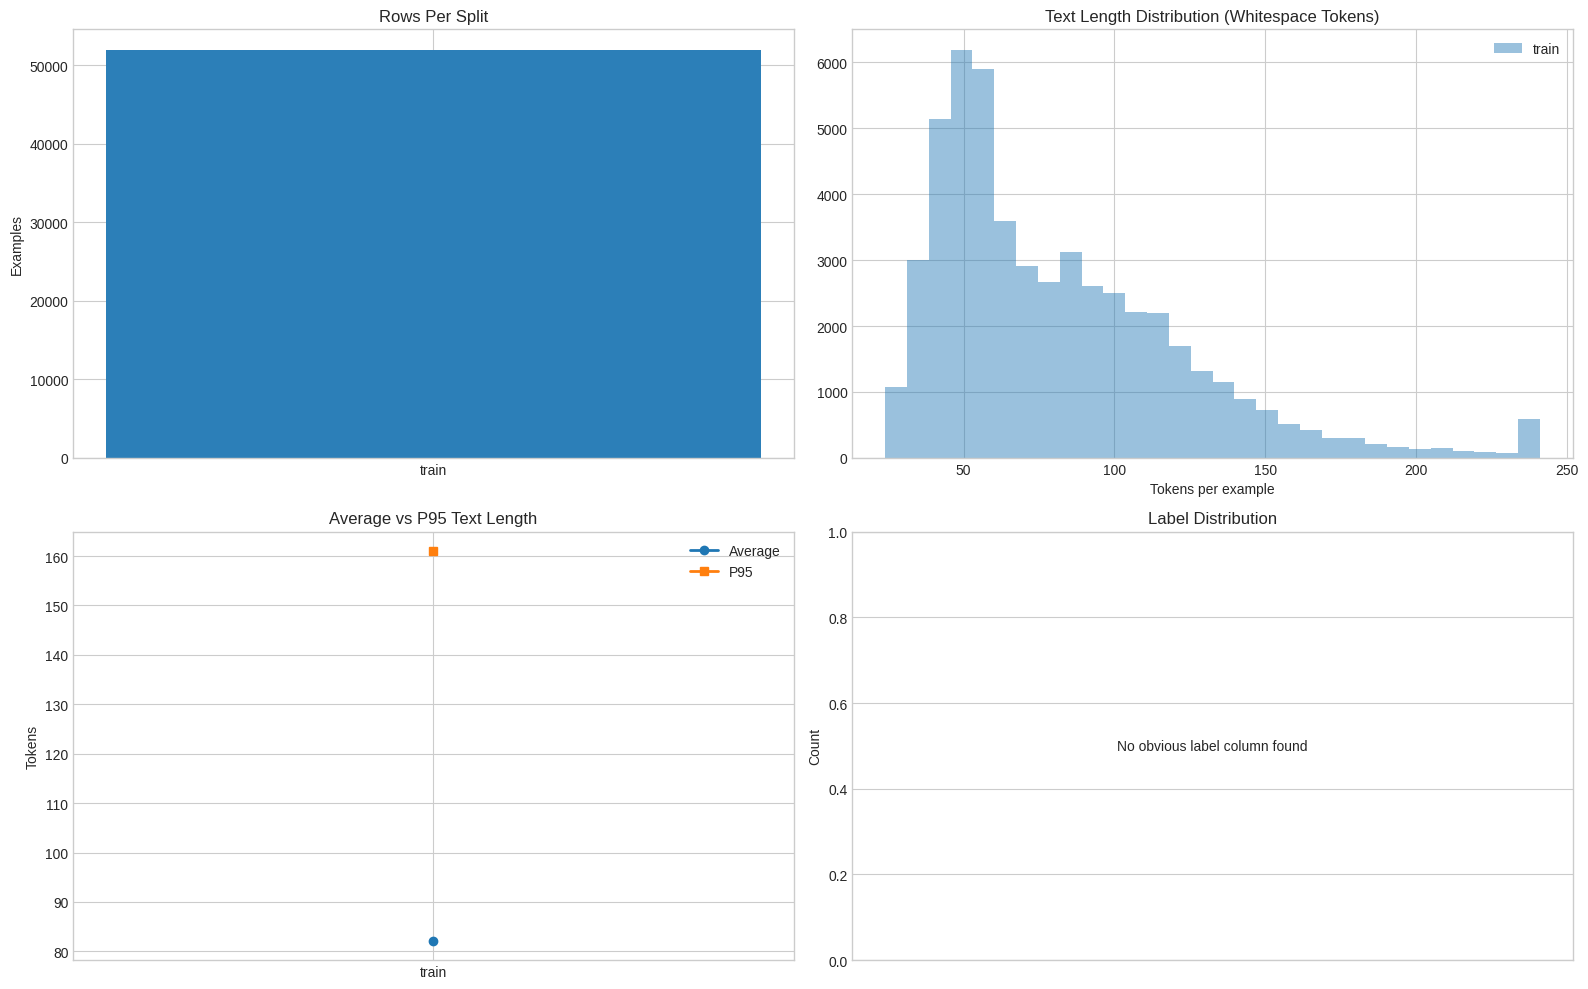

In [5]:
splits = load_dataset_splits(DATASET_PATH)
overview, split_details = make_dataset_overview(splits)

display(Markdown(f'## Dataset: `{DATASET_PATH}`'))
display(overview)

display(Markdown('### Dataset Insights'))
for insight in dataset_insights(splits, overview, split_details):
    display(Markdown(f'- {insight}'))

plot_dataset_views(splits, split_details)


In [6]:
display(Markdown('## Dataset Samples'))
for split_name, df in sorted(splits.items()):
    display(Markdown(f'### Split: `{split_name}`'))
    display(df.head(MAX_SAMPLE_ROWS))
    text_columns = split_details[split_name]['text_columns']
    if text_columns:
        top_tokens = top_tokens_from_text(split_details[split_name]['combined_text'], top_n=TOP_N_TOKENS)
        if not top_tokens.empty:
            display(Markdown(f'**Top tokens from {split_name} text preview**'))
            display(top_tokens)


## Dataset Samples

### Split: `train`

,instruction,input,output,text
0,Give three tips for staying healthy.,,1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your...,Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Ins...
1,What are the three primary colors?,,"The three primary colors are red, blue, and yellow.",Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Ins...
2,Describe the structure of an atom.,,"An atom is made up of a nucleus, which contains protons and neutrons, surrounded by electrons that travel in orbits ...",Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Ins...
3,How can we reduce air pollution?,,"There are a number of ways to reduce air pollution, such as shifting to renewable energy sources, encouraging the us...",Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Ins...
4,Describe a time when you had to make a difficult decision.,,I had to make a difficult decision when I was working as a project manager at a construction company. I was in charg...,Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Ins...


**Top tokens from train text preview**

,token,count
0,the,8931
1,that,5717
2,response,4019
3,instruction,4004
4,and,4001
5,write,2142
6,task,2038
7,below,2027
8,describes,2012
9,request,2006


In [7]:
model_info = load_model_info(MODEL_PATH)

display(Markdown(f'## Model: `{model_info["model_dir"]}`'))
display(model_info_table(model_info))

display(Markdown('### Model Insights'))
for insight in model_dataset_fit_insights(model_info, split_details):
    display(Markdown(f'- {insight}'))

display(Markdown('### Model Files'))
display(model_info['model_files'])


display(Markdown('### Attention Layer Weights'))
attention_weights, attention_notes = collect_attention_weight_shapes(
    model_info,
    layer_limit=ATTENTION_LAYER_LIMIT,
    allow_large_pth=LOAD_LARGE_PTH_FOR_ATTENTION_SHAPES,
)
for note in attention_notes:
    display(Markdown(f'- {note}'))
if attention_weights.empty:
    display(Markdown('No attention weights were found or inferred for this model.'))
else:
    display(attention_weights)


## Model: `/home/pkunwar/characterize_ttlora/llama2-7b/checkpoints`

,field,value
0,model_dir,/home/pkunwar/characterize_ttlora/llama2-7b/checkpoints
1,model_format,llama_original
2,model_type,llama
3,architectures,[LLaMA]
4,hidden_size,4096
5,num_hidden_layers,32
6,num_attention_heads,32
7,intermediate_size,None
8,vocab_size,-1
9,tokenizer_vocab_size,32000


### Model Insights

- P95 text length stays within the model context window (161.0 vs 4096).

- This is a causal/generative model family, so long-context and next-token behavior matter most.

...

### Model Files

,file,size_mb
0,.gitattributes,0.00
1,LICENSE.txt,0.01
2,README.md,0.02
3,Responsible-Use-Guide.pdf,1.20
4,USE_POLICY.md,0.00
5,checklist.chk,0.00
6,consolidated.00.pth,12852.60
7,params.json,0.00
8,tokenizer.model,0.48
9,tokenizer_checklist.chk,0.00


### Attention Layer Weights

- Original LLaMA attention shapes are inferred from params.json to avoid loading the large .pth checkpoint.

,source,weight_name,shape,num_parameters,inspection,layer,attention_heads
0,params.json,layers.0.attention.wq.weight,4096 x 4096,16777216.0,inferred_llama_original,0.0,32
1,params.json,layers.0.attention.wk.weight,4096 x 4096,16777216.0,inferred_llama_original,0.0,32
2,params.json,layers.0.attention.wv.weight,4096 x 4096,16777216.0,inferred_llama_original,0.0,32
3,params.json,layers.0.attention.wo.weight,4096 x 4096,16777216.0,inferred_llama_original,0.0,32
4,params.json,layers.1.attention.wq.weight,4096 x 4096,16777216.0,inferred_llama_original,1.0,32
5,params.json,layers.1.attention.wk.weight,4096 x 4096,16777216.0,inferred_llama_original,1.0,32
6,params.json,layers.1.attention.wv.weight,4096 x 4096,16777216.0,inferred_llama_original,1.0,32
7,params.json,layers.1.attention.wo.weight,4096 x 4096,16777216.0,inferred_llama_original,1.0,32
8,params.json,layers.2.attention.wq.weight,4096 x 4096,16777216.0,inferred_llama_original,2.0,32
9,params.json,layers.2.attention.wk.weight,4096 x 4096,16777216.0,inferred_llama_original,2.0,32


## Dataset Fit To Tokenizer (sentencepiece.SentencePieceProcessor)

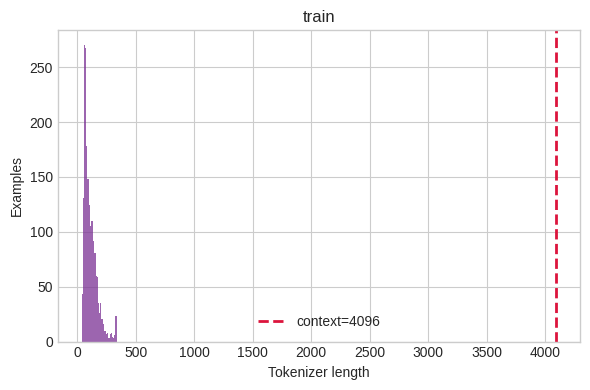

In [8]:
tokenizer = model_info.get('tokenizer')
context_limit = model_info.get('max_position_embeddings') or model_info.get('n_positions') or model_info.get('tokenizer_model_max_length')
use_tokenizer = tokenizer is not None
if use_tokenizer:
    display(Markdown(f'## Dataset Fit To Tokenizer ({model_info.get("tokenizer_backend")})'))
else:
    reason = model_info.get('tokenizer_error') or 'No tokenizer files or tokenizer library were available.'
    display(Markdown(f'Tokenizer could not be loaded, so this section uses whitespace-token lengths instead. Reason: `{reason}`'))

fig, axes = plt.subplots(1, len(split_details), figsize=(6 * max(len(split_details), 1), 4), squeeze=False)
axes = axes.flatten()
for axis, (split_name, detail) in zip(axes, sorted(split_details.items())):
    if use_tokenizer:
        token_lengths = token_lengths_with_model(detail['combined_text'], tokenizer, sample_limit=TOKEN_LENGTH_SAMPLE_LIMIT)
        xlabel = 'Tokenizer length'
    else:
        token_lengths = detail['token_lengths'].head(TOKEN_LENGTH_SAMPLE_LIMIT)
        xlabel = 'Whitespace-token length'

    if token_lengths.empty:
        axis.text(0.5, 0.5, 'No text columns detected', ha='center', va='center', transform=axis.transAxes)
        axis.set_title(split_name)
        continue

    clipped = token_lengths.clip(upper=token_lengths.quantile(0.99))
    axis.hist(clipped, bins=30, color='#7b3294', alpha=0.75)
    if isinstance(context_limit, int):
        axis.axvline(context_limit, color='crimson', linestyle='--', linewidth=2, label=f'context={context_limit}')
        axis.legend()
    axis.set_title(split_name)
    axis.set_xlabel(xlabel)
    axis.set_ylabel('Examples')
plt.tight_layout()
plt.show()
